### Implementing simple LangGraph Chatbot

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# Reducers
from typing import Annotated
from langgraph.graph.message import add_messages


In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages] # returns a list of messages being stored

In [3]:
import os 
from dotenv import load_dotenv

load_dotenv()

groq_key = os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")

In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant")
llm.invoke("What is India's capital? What is the AQI?")

AIMessage(content='India\'s capital is New Delhi. \n\nHowever, I need more information to provide the current AQI (Air Quality Index) in New Delhi. AQI can vary greatly depending on several factors, including location, time of day, and weather conditions.\n\nIf you\'re looking for the current AQI in New Delhi, I can suggest a few options:\n\n1. Check the official website of the Central Pollution Control Board (CPCB) of India: [www.cpcbccr.com](http://www.cpcbccr.com)\n2. Use a reliable air quality app such as AirNow, AirVisual, or SAFAR (System of Air Quality and Weather Forecasting And Research)\n3. Search online for "New Delhi AQI" or "New Delhi air quality" along with the current date to find the latest information.\n\nPlease note that AQI can change rapidly, and the information may not be up-to-date.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 187, 'prompt_tokens': 47, 'total_tokens': 234, 'completion_time': 0.303064997, 'completion_tokens_detail

### Start creating Nodes


In [5]:
def superbot(state: State):
    return {
        "messages": [
            llm.invoke(state["messages"])
        ]
    }

### Graph Contstruction

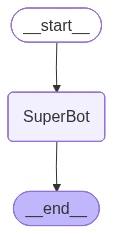

In [6]:
graph = StateGraph(State)

# Adding graph Nodes
graph.add_node("SuperBot", superbot) 
# Adding graph Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile()


# Visualizing the Graph
from IPython.display import display, Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [7]:
# Invocation
graph_builder.invoke({
    "messages": "Hello i'm Anurag, and i'm a Software Engineer."
})

{'messages': [HumanMessage(content="Hello i'm Anurag, and i'm a Software Engineer.", additional_kwargs={}, response_metadata={}, id='0c0b20a1-7e0c-4f09-8fa6-448d9a67052b'),
  AIMessage(content="Hello Anurag, nice to meet you. As a Software Engineer, you're likely working on building software applications or systems that meet specific requirements. What kind of projects or technologies are you currently working on? Do you have any specific interests or areas of specialization within the field of software engineering?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 49, 'total_tokens': 109, 'completion_time': 0.091486425, 'completion_tokens_details': None, 'prompt_time': 0.002435373, 'prompt_tokens_details': None, 'queue_time': 0.046156807, 'total_time': 0.093921798}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'gro

In [8]:
graph_builder.invoke({
    "messages": "Do you remeber my name?"
})

{'messages': [HumanMessage(content='Do you remeber my name?', additional_kwargs={}, response_metadata={}, id='8a74b79e-1d9c-4eb7-82b3-cedb24368c2e'),
  AIMessage(content="This is the beginning of our conversation, so I don't have any information about you, including your name. I'm happy to chat with you, though. Would you like to share your name with me?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 43, 'total_tokens': 86, 'completion_time': 0.121753285, 'completion_tokens_details': None, 'prompt_time': 0.003349205, 'prompt_tokens_details': None, 'queue_time': 0.046689585, 'total_time': 0.12510249}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ce7ff-fc7d-76e0-af41-0147f668a1bb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 43, 'total_tokens'

In [9]:
# Streaming the messages
for event in graph_builder.stream({
    "messages": "Hello i'm Anurag"
}, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content="Hello i'm Anurag", additional_kwargs={}, response_metadata={}, id='24e685d5-bcc1-45bb-9d56-9c2a06c42cc7')]}
{'messages': [HumanMessage(content="Hello i'm Anurag", additional_kwargs={}, response_metadata={}, id='24e685d5-bcc1-45bb-9d56-9c2a06c42cc7'), AIMessage(content='Nice to meet you, Anurag. Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 41, 'total_tokens': 66, 'completion_time': 0.040427762, 'completion_tokens_details': None, 'prompt_time': 0.00746004, 'prompt_tokens_details': None, 'queue_time': 0.05089278, 'total_time': 0.047887802}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ce7ff-fd53-7230-9b03-542bb591f9bb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens':

In [10]:
for event in graph_builder.stream({
    "messages": "What is my name?"
}, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='9f0f8c1e-b72e-4f6d-97bb-6e4b0567aa57')]}
{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='9f0f8c1e-b72e-4f6d-97bb-6e4b0567aa57'), AIMessage(content="I don't have any information about your name. I'm a text-based AI assistant and our conversation has just started. I don't retain any information about individual users, so I don't know your name. If you'd like to share it, I'd be happy to chat with you.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 40, 'total_tokens': 100, 'completion_time': 0.096658285, 'completion_tokens_details': None, 'prompt_time': 0.001851914, 'prompt_tokens_details': None, 'queue_time': 0.045457825, 'total_time': 0.098510199}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', '